# 유저 세그먼테이션 연습

캐글에 있는 데이터를 바탕으로 유저 세그먼테이션을 연습하려고 한다.
클러스터링도 가능할 것이고 다양한 방향으로도 가능할 것이다.

## 세그먼테이션 이론

유저 세그먼테이션은 기본적으로 동일한 속성을 가진 유저들끼리 그룹화(군집화) 시키는 과정이다.
이를 바탕으로 정교한 사용자 타케팅 등을 기대할 수 있다.

### 인구 통계학적 세그먼테이션

남성/여성, 연령대 등 인구 통계 기반의 세그먼테이션이 가능하다. 회원 가입시 간단한 설문조사 등을 바탕으로 쉽게 얻어낼 수 있는 정보.
다만 해당 정보로 큰 인사이트를 얻기는 쉽지 않고, 우리 서비스가 주로 어떤 연령대를 보이는지로 알 수 있다.

### 행동 기반 세그먼테이션

온라인/모바일 플랫폼에서는 이용자의 트래킹이 가능하므로 행동 기반 세그먼테이션이 유효할 것이다.

EX) 서비스 로그인 후 바로 이탈인지, 상품을 구경했는지, 실제 구매로 연결되었는지 등등 퍼널 단위의 세그먼테이션 가능

인구 통계학적 세그먼테이션 + 행동 기반 세그먼테션으로 강력한 인사이트를 획득할 수 있음이 기대된다.

EX) 20~30대 유입 유저가 가장 많으나 구매 이탈이 빈번하다는 것을 발견 -> 이를 해결하는 방법을 고려해보자.

즉, 세그먼테이션을 바탕으로 서비스의 문제점이나 주요 인사이트 사항을 발굴할 수 있을 것이다.

## Code Example : demographic segmentation

인구 통계/소득 정도의 데이터만 주어졌을 경우에는 군집화 알고리즘을 다양하게 적용하는 것이 중요할 것이다.
이에 따른 시각화 작업 또한 같이 병행되어야 할 것이다.이와 관련한 군집화 관련 코드 실습을 진행한다.

data : https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

In [1]:
import pandas as pd
df = pd.read_csv('C:/Users/USER/Desktop/TIL_new/data_analyst_practice/mall_customer_seg.csv')

In [2]:
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


성별, 연령, 연 소득 및 소득 점수로 구분되어 있다. 이에 관한 유저 세그먼테이션을 진행하자.

In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df['Gender'].value_counts()

Female    112
Male       88
Name: Gender, dtype: int64

데이터에는 어떤 결측치도 없으며, 성별은 1:1이기보다는 남성이 조금 더 적은 경향을 보인다.

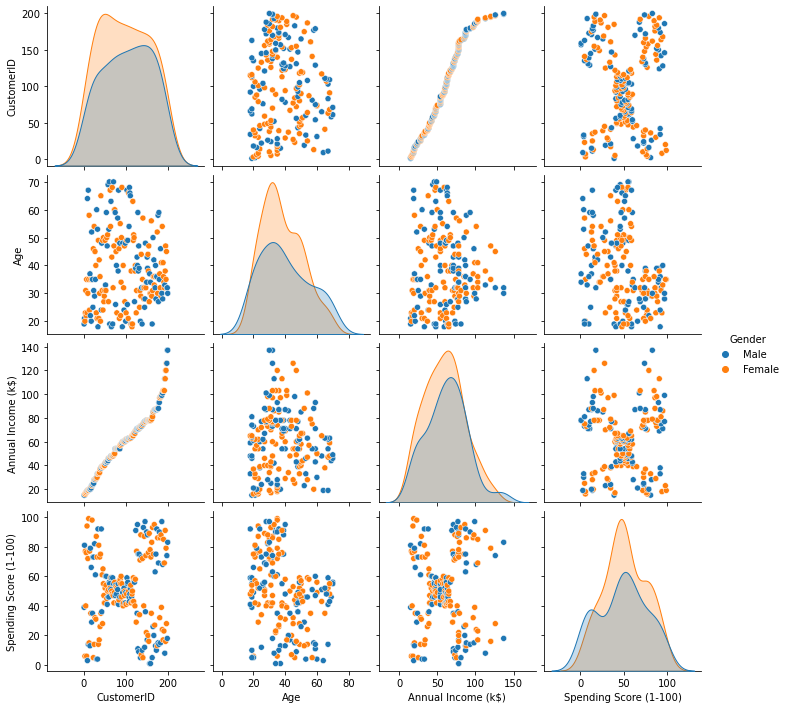

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df, hue = 'Gender')
plt.show()

데이터의 분포 확인과 성별에 다른 차이를 동시에 보고자 한다.
- 성별에 따른 차이는 크지 않지만, 20~40 대 사이의 여성 비중이 높음을 알 수 있다.
- 소득분포와 소득점수는 분포 자체는 이상치는 크게 안보이지만 스케일 값은 달라 정리가 필요하다.

상관관계를 확인하면 다음과 같다.

<AxesSubplot:>

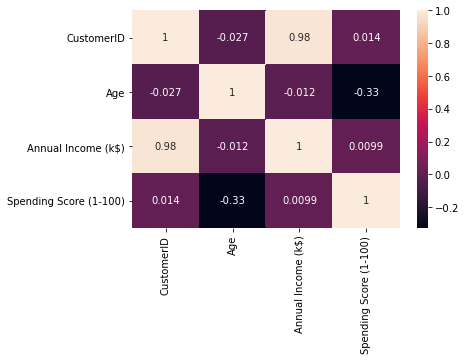

In [7]:
df_corr = df.corr()
sns.heatmap(df_corr, annot = True)

### K-means 활용

### 연령과 spending score에 따른 클러스터링

나이와, 소비점수에 따른 클러스터링을 우선적으로 진행해본다.
문제는 몇 개의 클러스터로 설정해야 좋을지에 대해 모르고, 클러스터가 어떻게 주어질지에 대한 정보도 필요하다.
따라서 클러스터 된 데이터에 대해 시각화를 진행해야 할 것이다.

In [8]:
from sklearn.cluster import KMeans
# 원본 데이터 보존을 위한 copy부터 실시
df_copy = df.copy()

군집화 평가기준인 inertia를 저장해서 보려고 한다. intertia값을 저장, elbow point에서 K값을 정하는 것이 적합하다.
또한 초기 포인트 설정에 좋은 k-means++로 init을 설정한다. 이것을 지정하면, 초기 포인트들은 각각 서로 거리가 먼 곳에서 결정될 확률이 높아진다.

In [9]:
df_cut = df[['Age', 'Spending Score (1-100)']]

In [10]:
from sklearn.cluster import KMeans
inertia_list = []

for K in range(2, 11, 1):
    clustering = KMeans(n_clusters = K, init = 'k-means++', random_state = 42, max_iter = 100)
    clustering.fit(df_cut)
    inertia_list.append(clustering.inertia_)

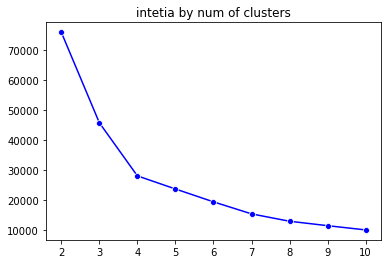

In [12]:
sns.lineplot(x=range(2,11,1), y=inertia_list,
            color = 'b', marker='o')
plt.title('intetia by num of clusters')
plt.show()

K=4 정도일때가 가장 적합하다. 4일때가 가장 적합할 것이다. 이제 이를 바탕으로 모델 학습 및 시각화를 진행해보자.

In [14]:
clustering = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42, max_iter = 100)
clustering.fit(df_cut)
df_cut['cluster'] = clustering.labels_

<ipython-input-14-78ea86eb1f97>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['cluster'] = clustering.labels_


<AxesSubplot:xlabel='Age', ylabel='Spending Score (1-100)'>

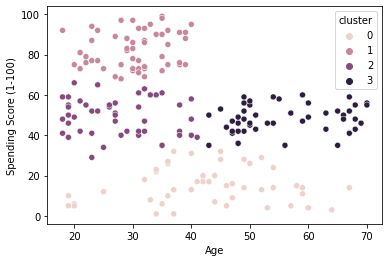

In [17]:
sns.scatterplot(x = 'Age', y = 'Spending Score (1-100)', hue = 'cluster', data = df_cut)

다음과 같이 4개의 그룹으로 나뉘어져 있음을 알 수 있다. 4개의 그룹은 다음과 같이 명명 가능할 것이다.
- Group 0 : 저소비 그룹
- Group 1 : 저연령 중간 소비 그룹
- Group 2 : 고연령 중간 소비 그룹
- Group 3 : 저연령 고소비 그룹

비슷한 방식으로 다른 clustering도 적용해보자.

### 연령과 소득에 따른 clustering

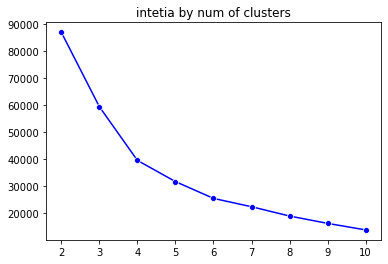

In [19]:
df_cut = df[['Age', 'Annual Income (k$)']]
inertia_list = []

for K in range(2, 11, 1):
    clustering = KMeans(n_clusters = K, init = 'k-means++', random_state = 42, max_iter = 100)
    clustering.fit(df_cut)
    inertia_list.append(clustering.inertia_)
    
sns.lineplot(x=range(2,11,1), y=inertia_list,
            color = 'b', marker='o')
plt.title('intetia by num of clusters')
plt.show()

이 역시 비슷하게 4~5개 정도의 클러스터로 구분하는 것이 좋아보인다.

<ipython-input-24-3f41f921727a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['cluster'] = clustering.labels_


<AxesSubplot:xlabel='Age', ylabel='Annual Income (k$)'>

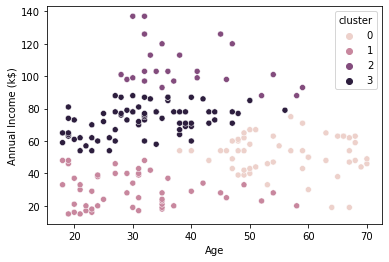

In [24]:
clustering = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42, max_iter = 100)
clustering.fit(df_cut)
df_cut['cluster'] = clustering.labels_
sns.scatterplot(x = 'Age', y = 'Annual Income (k$)', hue = 'cluster', data = df_cut)

### 3가지 변수 모두 사용 - 실루엣 계수의 사용

3가지 변수를 모두 사용해보려고 한다.

이번에는 실루엣 계수를 바탕으로 판정하자.
실루엣 계수는 기본적으로 각 샘플들의 클러스터 내부에서의 거리와, 인접 클러스터와의 거리를 기반으로 산출된다.
1에 가까울 수록 좋은 값이며 음수 값이 나왔을 경우 클러스터링에 실패한 것이다.

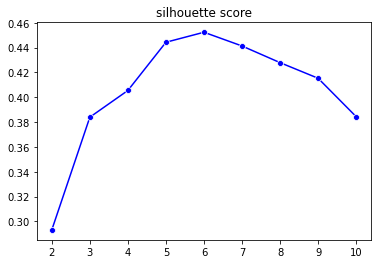

In [27]:
# 모든 실루엣 값의 평균값을 구하는 방법
from sklearn.metrics import silhouette_score
df_cut = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
num_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
score_list = []

for K in num_clusters:
    clustering = KMeans(n_clusters = K, init = 'k-means++', random_state = 42, max_iter = 100)
    clustering.fit(df_cut)
    cur_sil = silhouette_score(df_cut, clustering.labels_, metric = 'euclidean')
    score_list.append(cur_sil)
    
sns.lineplot(x=range(2,11,1), y=score_list,
            color = 'b', marker='o')
plt.title('silhouette score')
plt.show()

이 경우, 평균 score가 높은 6의 지점을 선택하는 것도 방법이다. 실제 그룹화가 유의미하게 되었는지 다른 방법으로 확인해보자.

<AxesSubplot:xlabel='cluster', ylabel='Spending Score (1-100)'>

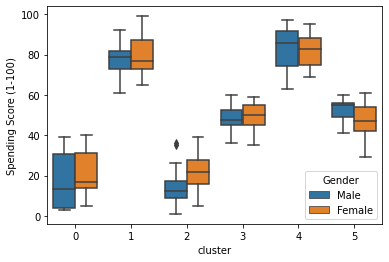

In [29]:
# 각 cluster의 남/녀 별로 소비점수의 폭을 살펴보자
clustering = KMeans(n_clusters = 6, init = 'k-means++', random_state = 42, max_iter = 100)
clustering.fit(df_cut)
# 이번에는 성별 변수도 쓰기 위해 원본에 붙인다.
df['cluster'] = clustering.labels_
sns.boxplot(x='cluster', y='Spending Score (1-100)', hue = 'Gender', data = df)

소비 점수가 낮은 그룹이 0,2  중간이 3,5, 높은 그룹이 1,4로 배정받았다. 이들을 유의미하게 구분할 수 있을까? 연령대롤 보자.

<AxesSubplot:xlabel='cluster', ylabel='Annual Income (k$)'>

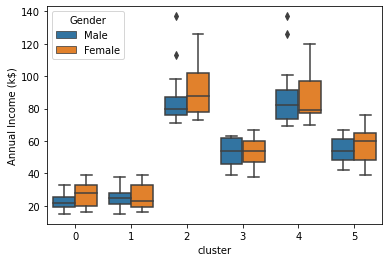

In [32]:
sns.boxplot(x='cluster', y='Annual Income (k$)', hue = 'Gender', data = df)

0번과 2번 / 1번과 4번은 구분이 가나 3번과 5번의 구분이 아직 필요하다.

<AxesSubplot:xlabel='cluster', ylabel='Age'>

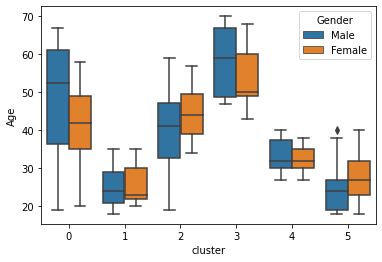

In [34]:
sns.boxplot(x='cluster', y='Age', hue = 'Gender', data = df)

3번과 5번인 구분이 되었다.

- 0번 : 연소득과 소비점수가 낮은 그룹
- 1번 : 연소득은 낮으나 소비점수가 높은 그룹 -> 젋은 계층에 주로 분포 (Target)
- 2번 : 연소득은 높으나 소비점수가 낮은 그룹
- 3번 : 연소득과 소비점수가 중간대인 고연령 그룹
- 4번 : 연소득과 소비점수가 모두 높은 그룹 -> 젊은 계층에 주로 분포 (1번보다는 나이가 있음)
- 5번 : 연소득과 소비점수가 중간대인 저연령 그룹

1,3,4번 그룹에 대한 고려를 자세히 들어가면 되는 것으로 초기 인사이트를 볼 수 있을것이다.